# Case Study: End-to-End ML Project (3 Small Case Studies)

## 1. Regression: Housing Price Prediction

### Problem Definition
In this case study, we'll develop a regression model to predict house prices based on various features of the property.

### Dataset
We'll use the California Housing dataset available in scikit-learn, containing information about houses in California from the 1990 census.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the California Housing dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print(f"Dataset shape: {X.shape}")
print(f"Features: {X.columns.tolist()}")

Dataset shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


### Exploratory Data Analysis

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704  
std       10.386050      2.135952      2.003532  
min        0.692308     32.540000   -124.350000  
25%        2.429741     33.930000   -1

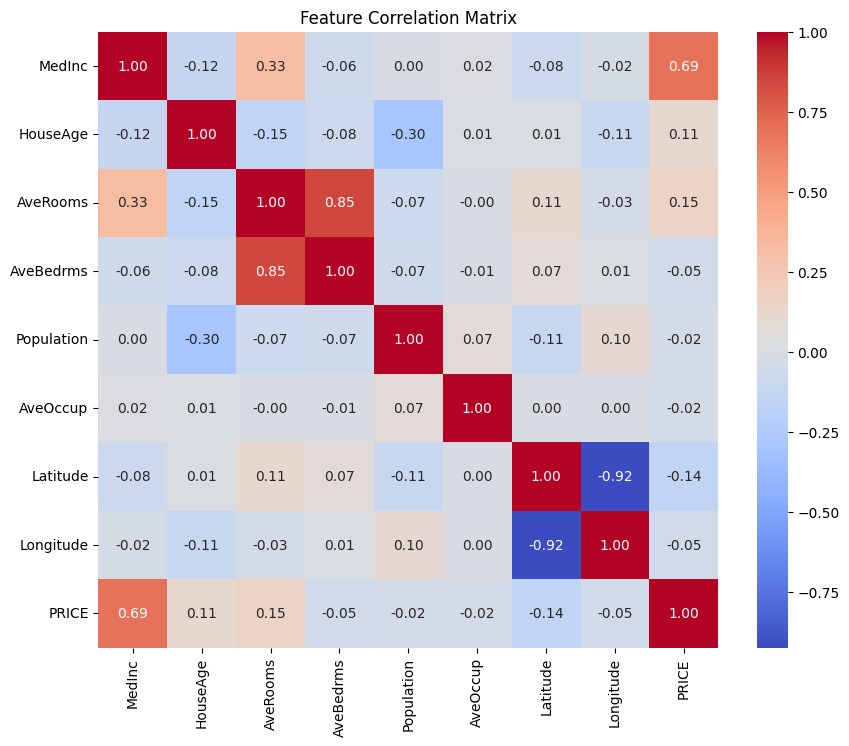

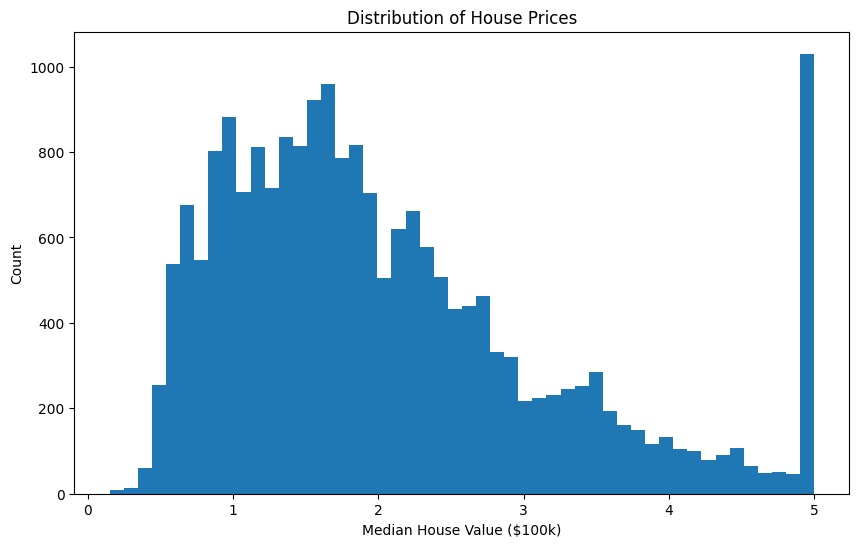

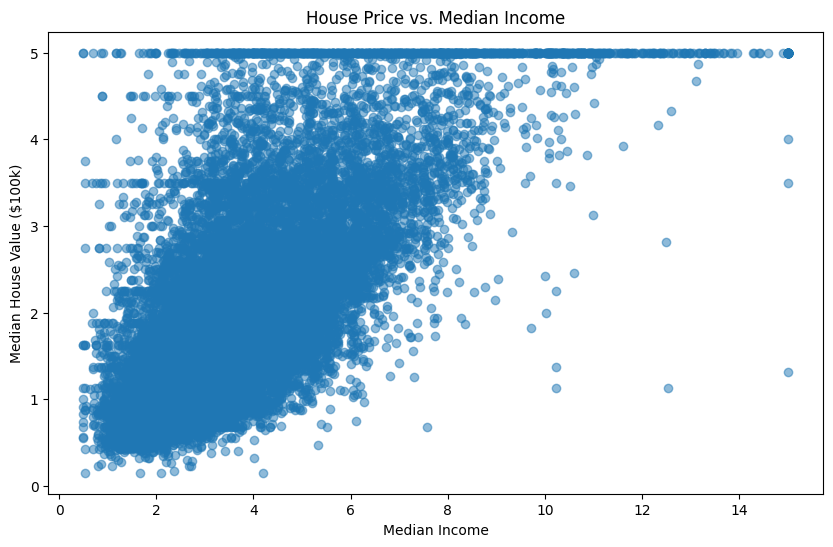

In [2]:
# Basic statistics
print(X.describe())

# Correlation with target
correlation = pd.DataFrame(X.values, columns=X.columns)
correlation['PRICE'] = y
plt.figure(figsize=(10, 8))
sns.heatmap(correlation.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

# Distribution of target variable
plt.figure(figsize=(10, 6))
plt.hist(y, bins=50)
plt.xlabel('Median House Value ($100k)')
plt.ylabel('Count')
plt.title('Distribution of House Prices')
plt.show()

# Relationship between median income and house price
plt.figure(figsize=(10, 6))
plt.scatter(X['MedInc'], y, alpha=0.5)
plt.xlabel('Median Income')
plt.ylabel('Median House Value ($100k)')
plt.title('House Price vs. Median Income')
plt.show()

### Data Preprocessing

In [3]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (16512, 8)
Testing set shape: (4128, 8)


### Model Development and Evaluation

Linear Regression RMSE: 0.7456
Linear Regression R²: 0.5758
Linear Regression Coefficients:
      Feature  Coefficient
0      MedInc     0.854383
3   AveBedrms     0.339259
1    HouseAge     0.122546
4  Population    -0.002308
5    AveOccup    -0.040829
2    AveRooms    -0.294410
7   Longitude    -0.869842
6    Latitude    -0.896929
Random Forest RMSE: 0.5051
Random Forest R²: 0.8053
Random Forest Feature Importance:
      Feature  Importance
0      MedInc    0.524871
5    AveOccup    0.138443
6    Latitude    0.088936
7   Longitude    0.088629
1    HouseAge    0.054593
2    AveRooms    0.044272
4  Population    0.030650
3   AveBedrms    0.029606


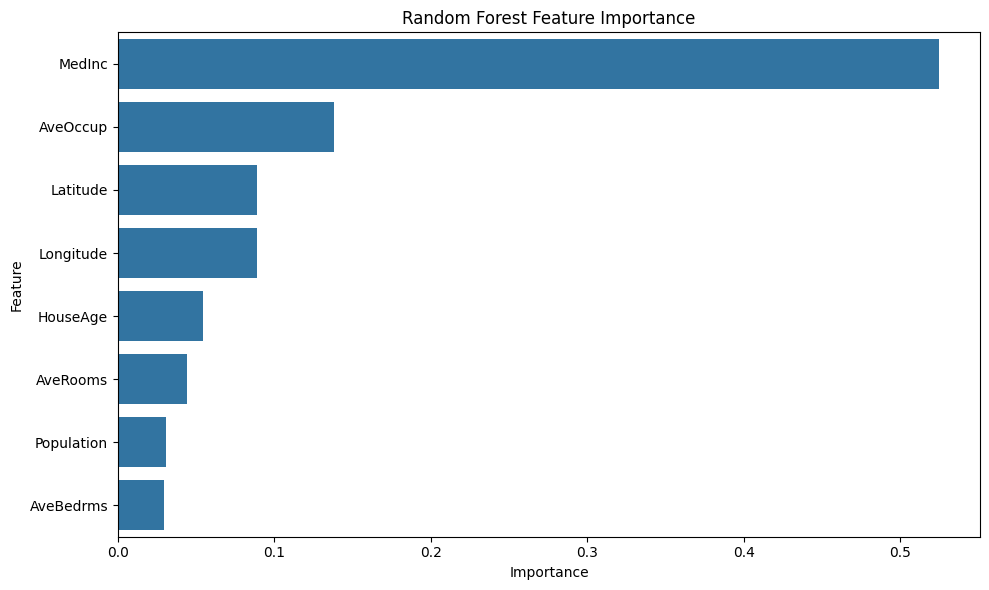

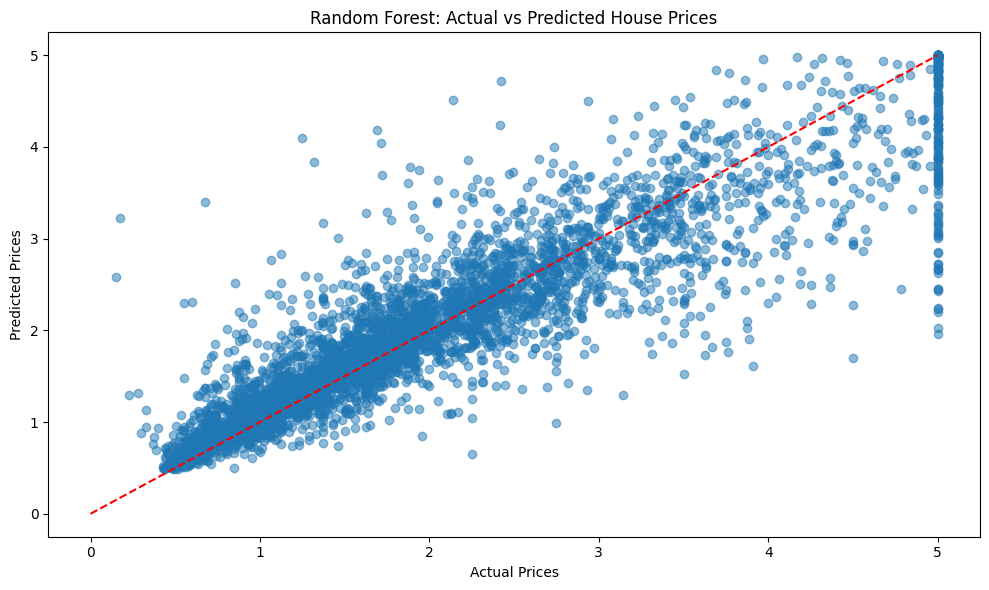

In [4]:
# Linear Regression model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print(f"Linear Regression RMSE: {lr_rmse:.4f}")
print(f"Linear Regression R²: {lr_r2:.4f}")

# Feature importance from linear regression
lr_coef = pd.DataFrame(
    {'Feature': X.columns, 'Coefficient': lr.coef_}
).sort_values('Coefficient', ascending=False)
print("Linear Regression Coefficients:")
print(lr_coef)

# Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest RMSE: {rf_rmse:.4f}")
print(f"Random Forest R²: {rf_r2:.4f}")

# Feature importance from random forest
feature_importance = pd.DataFrame(
    {'Feature': X.columns, 'Importance': rf.feature_importances_}
).sort_values('Importance', ascending=False)
print("Random Forest Feature Importance:")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

# Compare actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.plot([0, 5], [0, 5], 'r--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Random Forest: Actual vs Predicted House Prices')
plt.tight_layout()
plt.show()

### Key Insights

1. The Random Forest model outperformed Linear Regression, suggesting non-linear relationships in the data.
2. Median income is the most important predictor of house prices.
3. Location features (latitude and longitude) also significantly impact house prices.
4. The model can explain approximately 80% of the variance in house prices.

## 2. Classification: Customer Churn Prediction

### Problem Definition
In this case study, we'll develop a classification model to predict whether a telecom customer will churn (cancel service) based on their behavior and account characteristics.

### Dataset
We'll use the Telco Customer Churn dataset, a commonly used dataset in classification problems.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# For this example, we'll assume you've downloaded the dataset
# The dataset can be found at: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Basic information
print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

### Exploratory Data Analysis

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


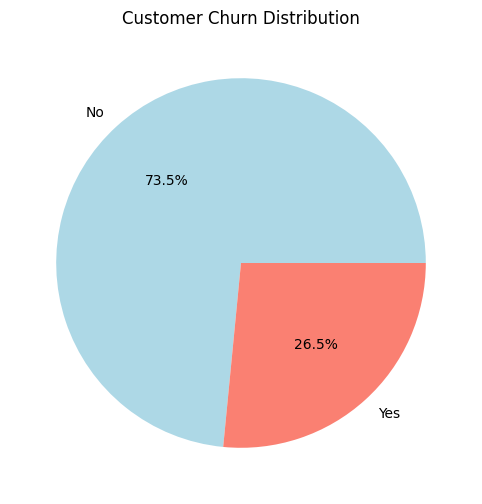

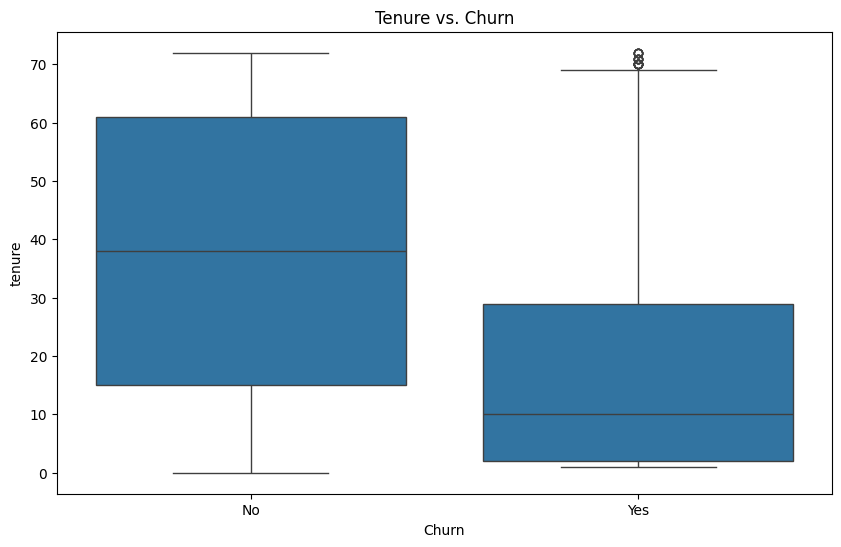

<Figure size 1000x600 with 0 Axes>

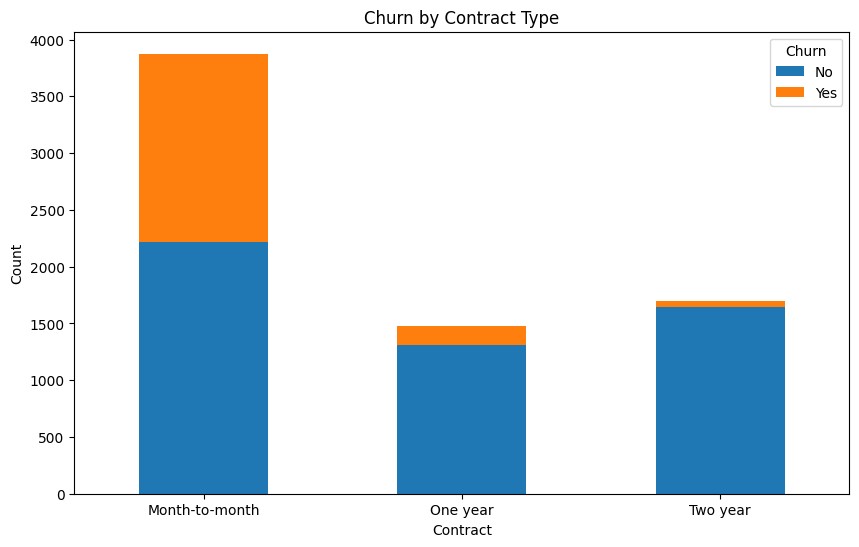

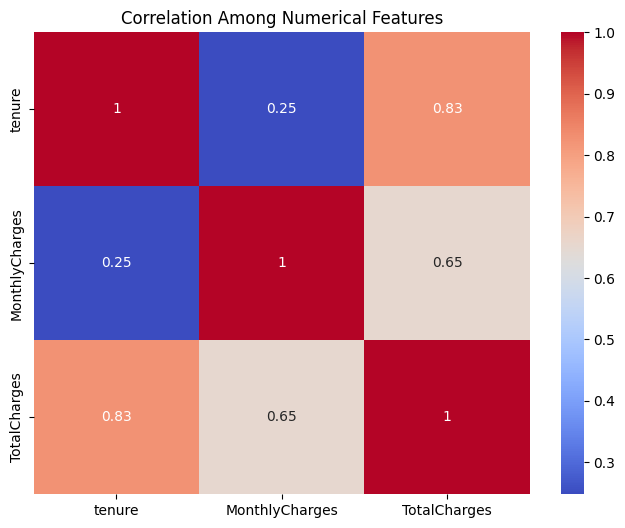

In [6]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Convert 'TotalCharges' to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# df['TotalCharges'].fillna(0, inplace=True)  # FutureWarning
df['TotalCharges'] = df['TotalCharges'].fillna(0)  # Updated to avoid FutureWarning

# Distribution of target variable (Churn)
plt.figure(figsize=(8, 6))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightblue', 'salmon'])
plt.title('Customer Churn Distribution')
plt.ylabel('')
plt.show()

# Relationship between tenure and churn
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs. Churn')
plt.show()

# Relationship between contract type and churn
plt.figure(figsize=(10, 6))
churn_by_contract = df.groupby(['Contract', 'Churn']).size().unstack()
churn_by_contract.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Churn by Contract Type')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.show()

# Correlation among numerical features
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Among Numerical Features')
plt.show()

```
FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.
```

### Data Preprocessing

In [7]:
# Drop unnecessary columns
df.drop('customerID', axis=1, inplace=True)

# Convert categorical target to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Split into features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Create preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

# Print sizes
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (5282, 19)
Testing set shape: (1761, 19)


### Model Development and Evaluation

Logistic Regression Performance:
Accuracy: 0.8069
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1294
           1       0.66      0.55      0.60       467

    accuracy                           0.81      1761
   macro avg       0.76      0.73      0.74      1761
weighted avg       0.80      0.81      0.80      1761

Random Forest Performance:
Accuracy: 0.7888
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1294
           1       0.63      0.49      0.55       467

    accuracy                           0.79      1761
   macro avg       0.73      0.69      0.71      1761
weighted avg       0.78      0.79      0.78      1761



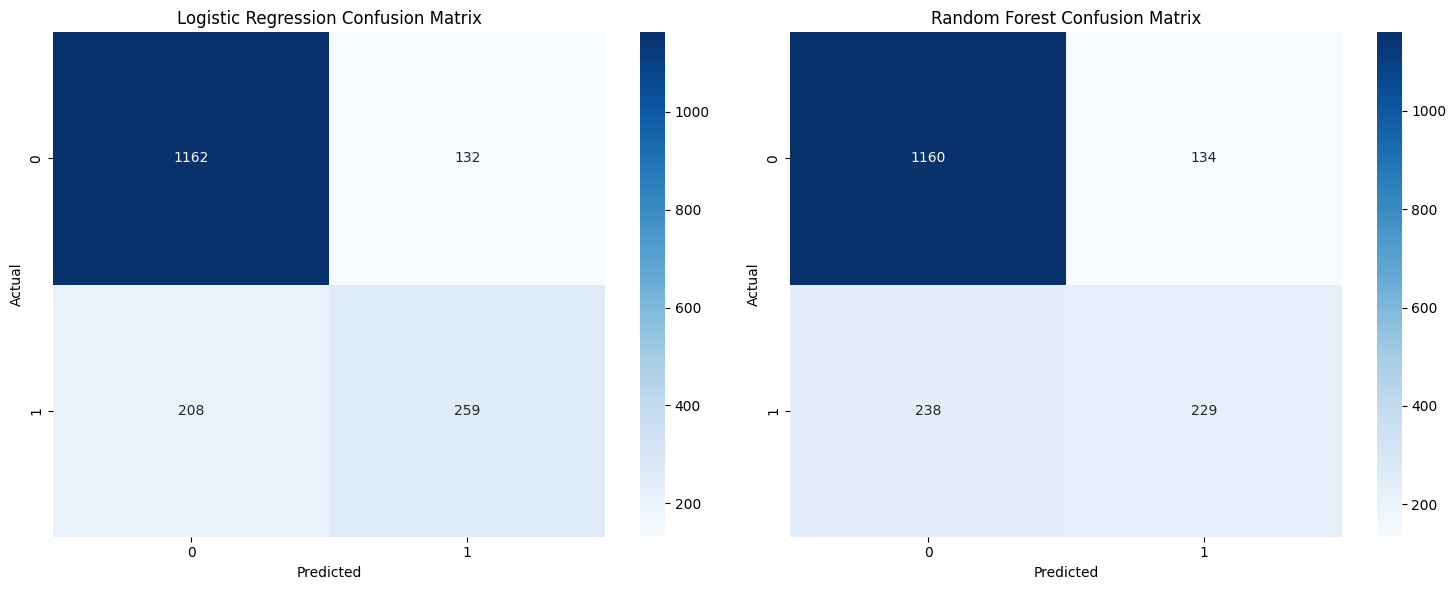

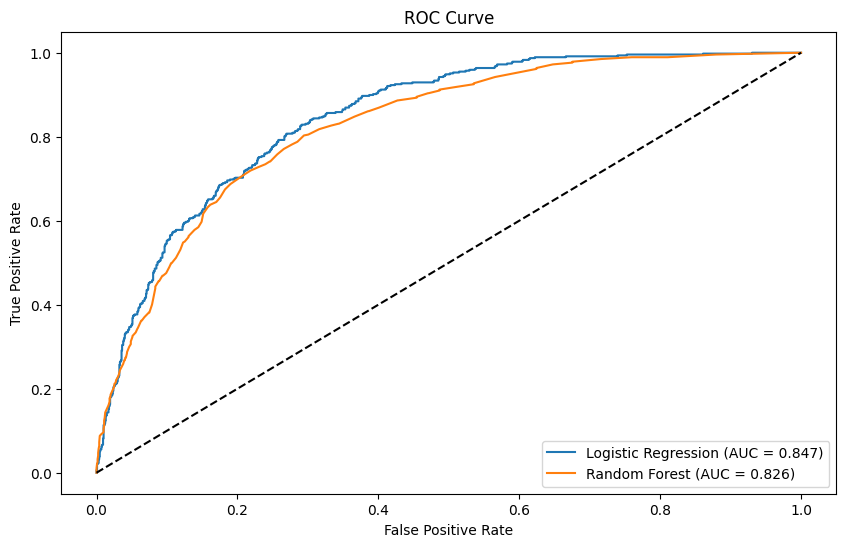

In [8]:
# Create and train Logistic Regression model with preprocessing pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])
lr_pipeline.fit(X_train, y_train)

# Predict on the test set
lr_pred = lr_pipeline.predict(X_test)
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]

# Evaluate Logistic Regression
print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(classification_report(y_test, lr_pred))

# Create and train Random Forest model with preprocessing pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)

# Predict on the test set
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluate Random Forest
print("Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(classification_report(y_test, rf_pred))

# Plot confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Logistic Regression confusion matrix
lr_cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Logistic Regression Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# Random Forest confusion matrix
rf_cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title('Random Forest Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Plot ROC curve
plt.figure(figsize=(10, 6))
# Calculate ROC curve for logistic regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
lr_roc_auc = auc(lr_fpr, lr_tpr)

# Calculate ROC curve for random forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
rf_roc_auc = auc(rf_fpr, rf_tpr)

# Plot both ROC curves
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_roc_auc:.3f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

### Feature Importance Analysis

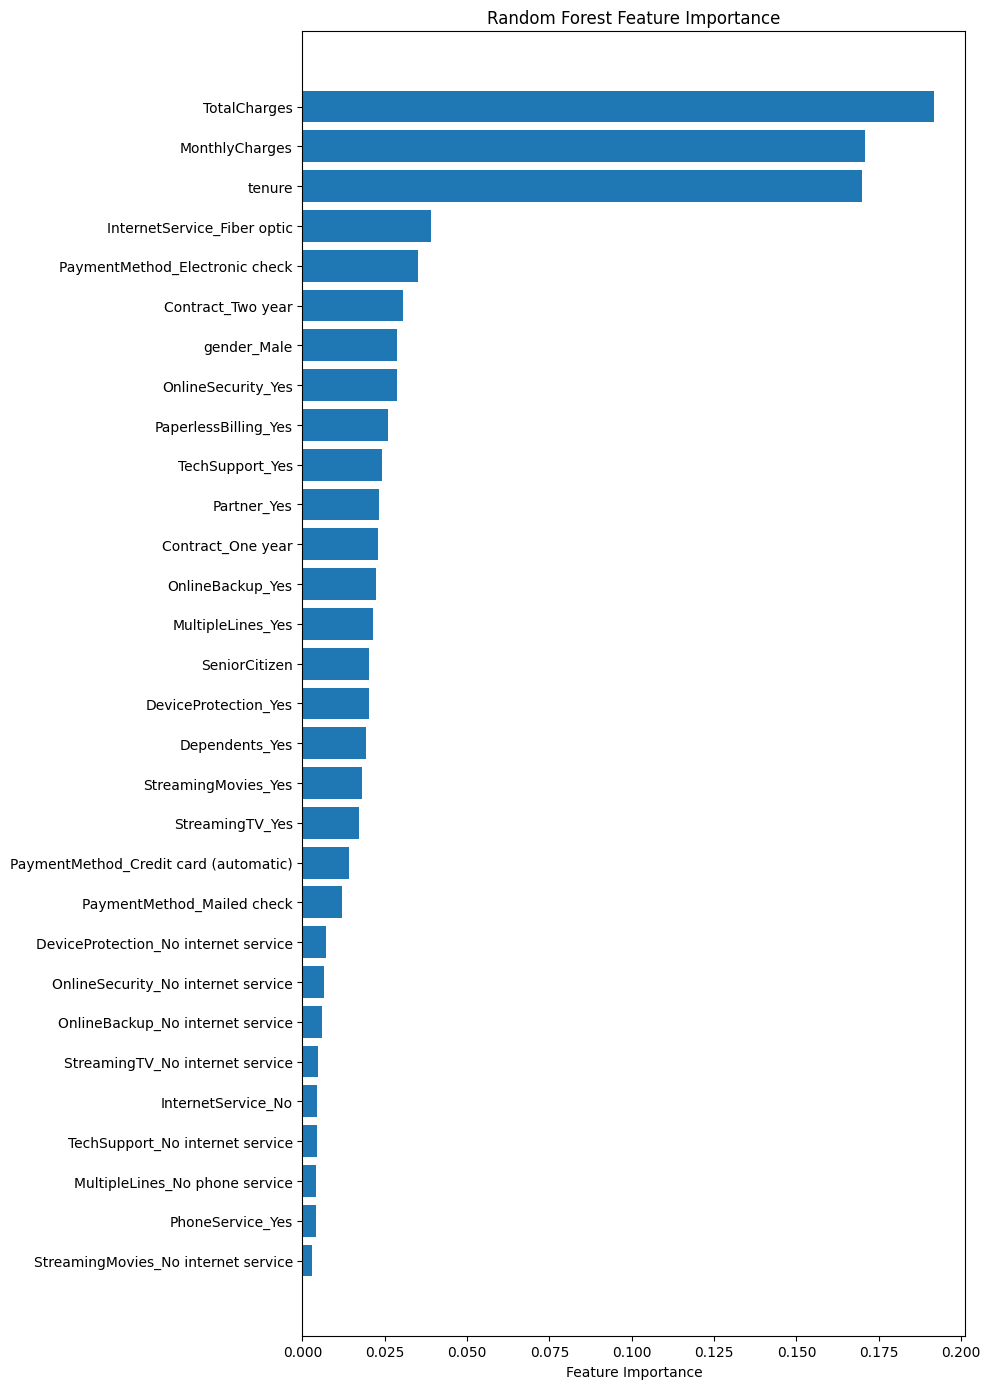

In [9]:
# Extract feature names after preprocessing
preprocessor.fit(X)
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
feature_names = np.append(numeric_cols, cat_features)

# Get feature importance from Random Forest
rf_pipeline.fit(X_train, y_train)
rf_feature_imp = rf_pipeline.named_steps['classifier'].feature_importances_

# Sort feature importances
sorted_idx = np.argsort(rf_feature_imp)
plt.figure(figsize=(10, 14))
plt.barh(range(len(sorted_idx)), rf_feature_imp[sorted_idx])
plt.yticks(range(len(sorted_idx)), feature_names[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

### Key Insights

1. Contract type and tenure are the most important predictors of customer churn.
2. Customers with month-to-month contracts are more likely to churn compared to those with longer-term contracts.
3. Customers with higher tenure are less likely to churn.
4. Random Forest slightly outperformed Logistic Regression but both achieve good results.

## 3. Clustering: Customer Segmentation for Retail

### Problem Definition
In this case study, we'll use clustering techniques to segment retail customers based on their purchasing behavior, allowing for targeted marketing strategies.

### Dataset
We'll use the Mall Customer Segmentation dataset, which includes basic demographic and spending information.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the dataset (available at: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)
df = pd.read_csv('Mall_Customers.csv')

# Rename columns for clarity
df = df.rename(columns={'Annual Income (k$)': 'Income', 'Spending Score (1-100)': 'Spending_Score'})

print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (200, 5)
   CustomerID  Gender  Age  Income  Spending_Score
0           1    Male   19      15              39
1           2    Male   21      15              81
2           3  Female   20      16               6
3           4  Female   23      16              77
4           5  Female   31      17              40


### Exploratory Data Analysis

       CustomerID         Age      Income  Spending_Score
count  200.000000  200.000000  200.000000      200.000000
mean   100.500000   38.850000   60.560000       50.200000
std     57.879185   13.969007   26.264721       25.823522
min      1.000000   18.000000   15.000000        1.000000
25%     50.750000   28.750000   41.500000       34.750000
50%    100.500000   36.000000   61.500000       50.000000
75%    150.250000   49.000000   78.000000       73.000000
max    200.000000   70.000000  137.000000       99.000000
Missing values per column:
CustomerID        0
Gender            0
Age               0
Income            0
Spending_Score    0
dtype: int64


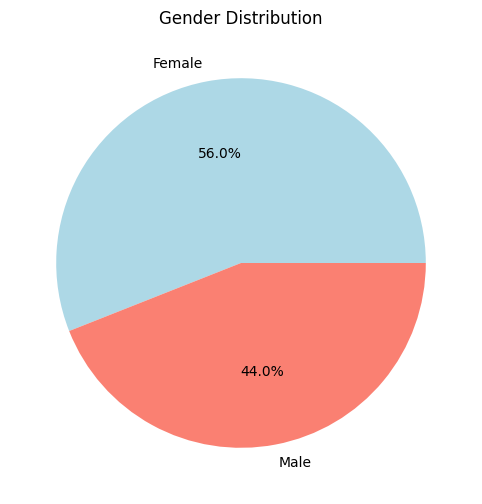

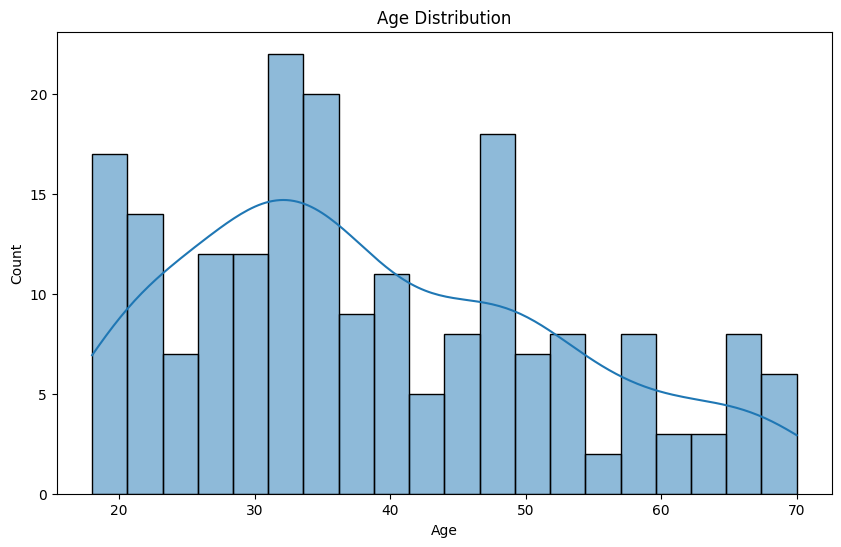

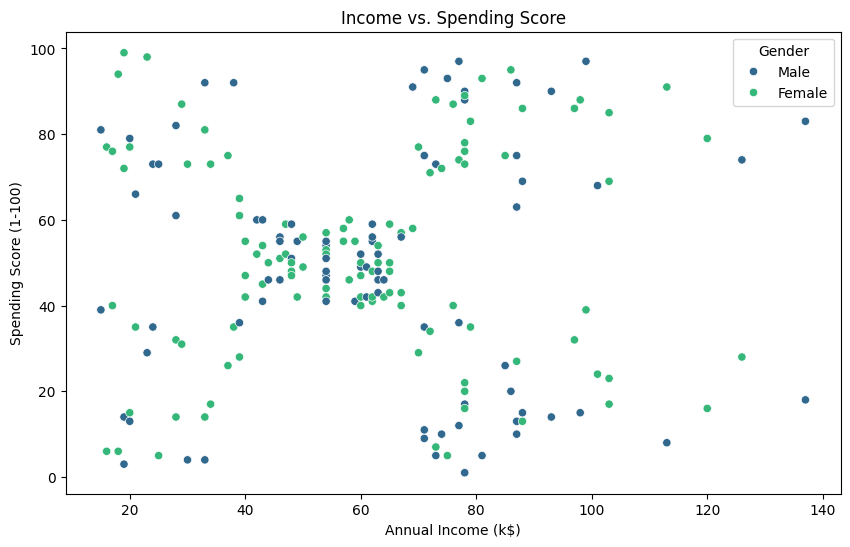

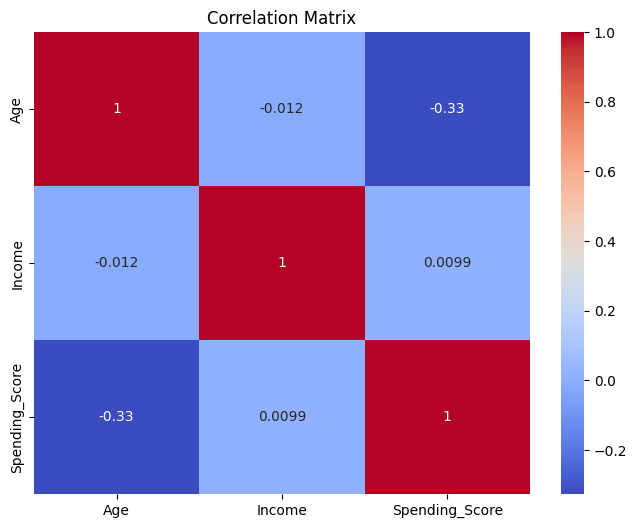

In [11]:
# Basic statistics
print(df.describe())

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Gender distribution
plt.figure(figsize=(8, 6))
df['Gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightblue', 'salmon'])
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

# Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Income vs. Spending Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Income', y='Spending_Score', hue='Gender', data=df, palette='viridis')
plt.title('Income vs. Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

# Correlation matrix
plt.figure(figsize=(8, 6))
corr = df[['Age', 'Income', 'Spending_Score']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Data Preprocessing

In [12]:
# Select features for clustering
X = df[['Income', 'Spending_Score']].copy()

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled features shape:", X_scaled.shape)

Scaled features shape: (200, 2)


### K-Means Clustering

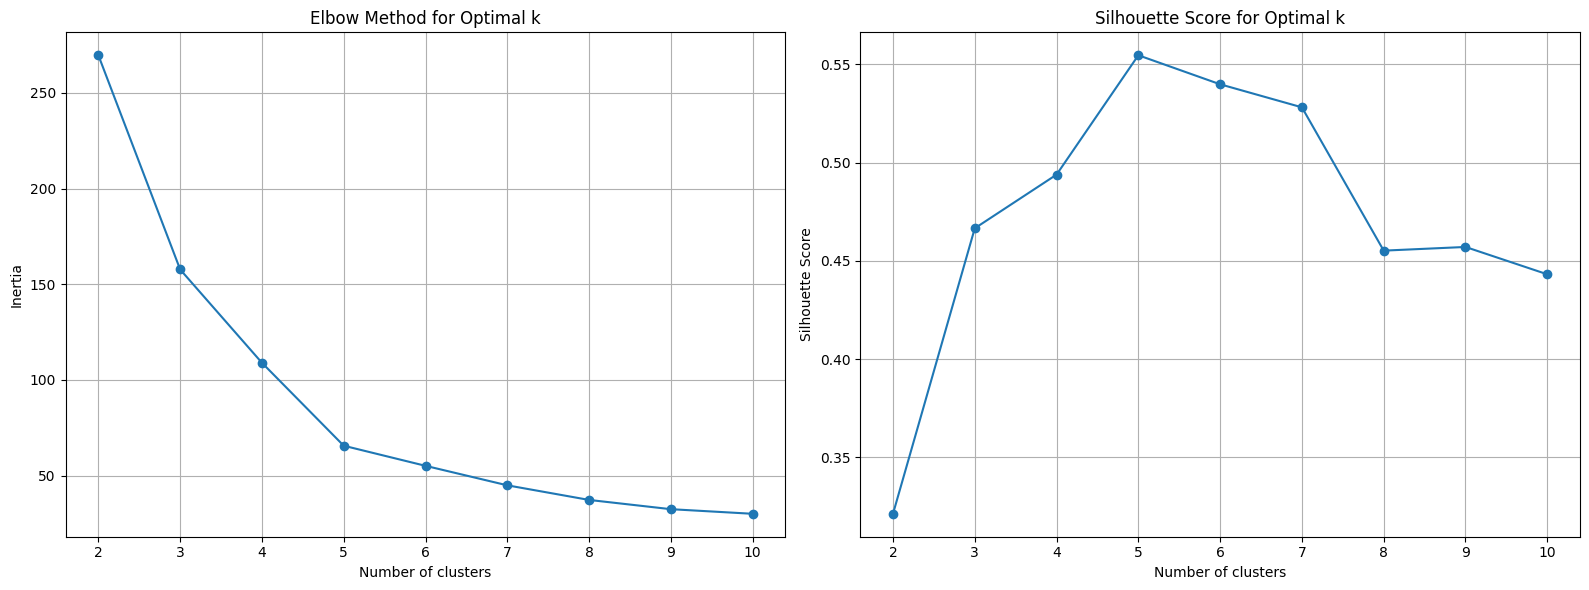

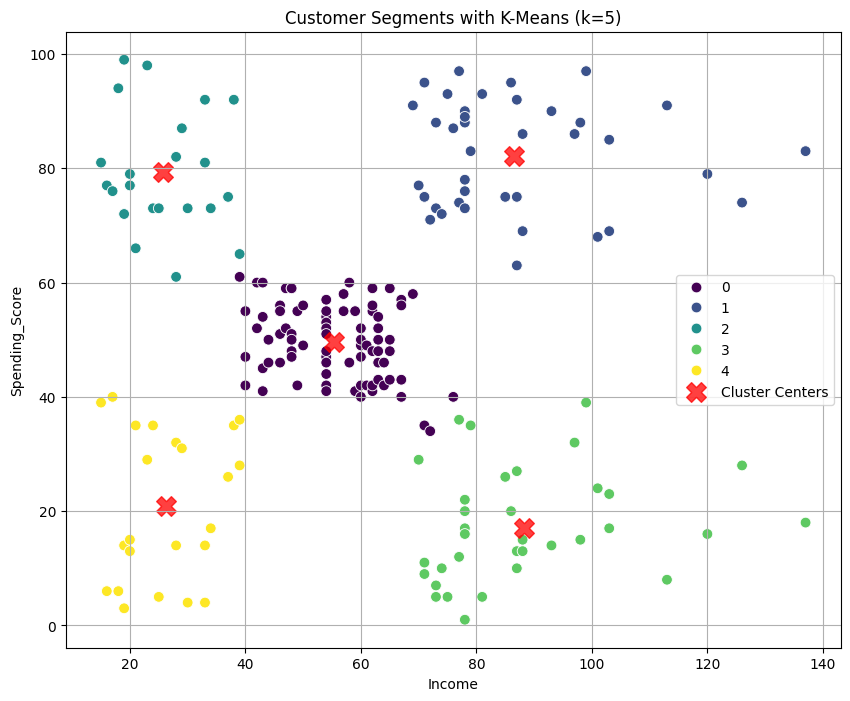

In [13]:
# Determine optimal number of clusters using the Elbow method
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow method
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.grid(True)

plt.tight_layout()
plt.show()

# Based on the elbow method and silhouette score, choose optimal k
optimal_k = 5  # Adjust based on the plots

# Apply K-means with the chosen k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

# Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Income', y='Spending_Score', hue='Cluster_KMeans', data=df, palette='viridis', s=60)
plt.title(f'Customer Segments with K-Means (k={optimal_k})')

# Plot cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Cluster Centers')
plt.legend()
plt.grid(True)
plt.show()

### Hierarchical Clustering

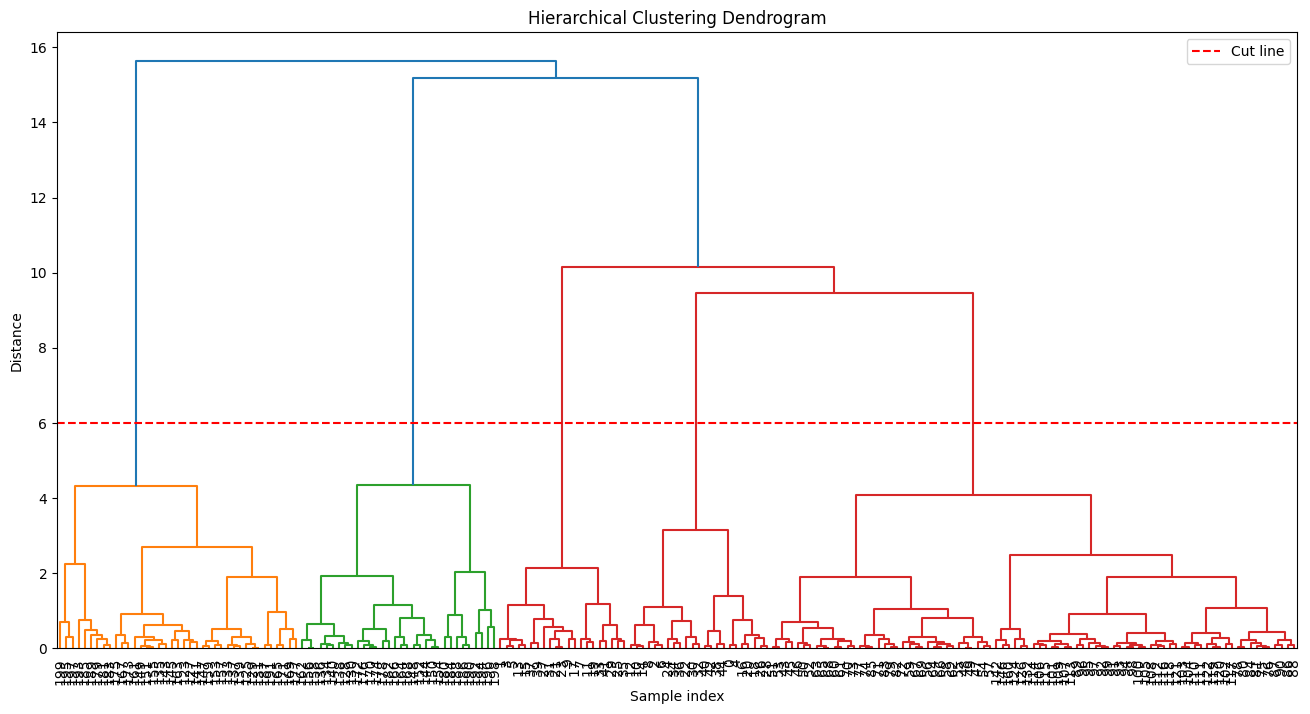

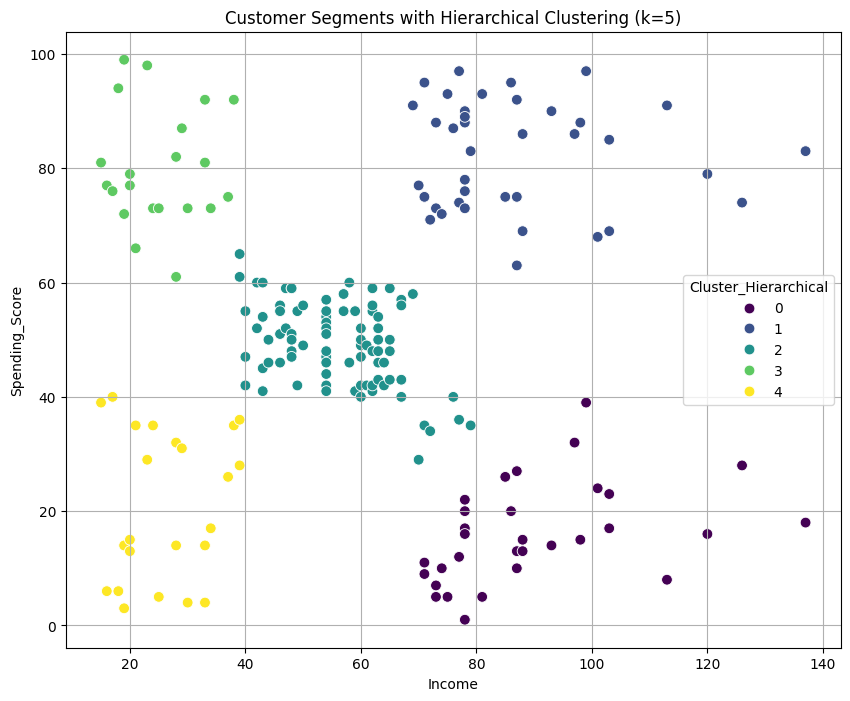

In [14]:
# Perform hierarchical clustering
# Generate linkage matrix
Z = linkage(X_scaled, method='ward')

# Plot dendrogram to help identify the number of clusters
plt.figure(figsize=(16, 8))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
dendrogram(Z, leaf_rotation=90., leaf_font_size=10.)
plt.axhline(y=6, color='r', linestyle='--', label='Cut line')
plt.legend()
plt.show()

# Apply Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df['Cluster_Hierarchical'] = agg_clustering.fit_predict(X_scaled)

# Visualize the hierarchical clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Income', y='Spending_Score', hue='Cluster_Hierarchical', data=df, palette='viridis', s=60)
plt.title(f'Customer Segments with Hierarchical Clustering (k={optimal_k})')
plt.grid(True)
plt.show()

#### Improved Dendrogram and Clustering Visualization
updated code with improvements for both the dendrogram and the scatterplot, using the top 30 clusters for visualization (via truncate_mode='lastp', p=30) and ensuring everything is readable and saved correctly

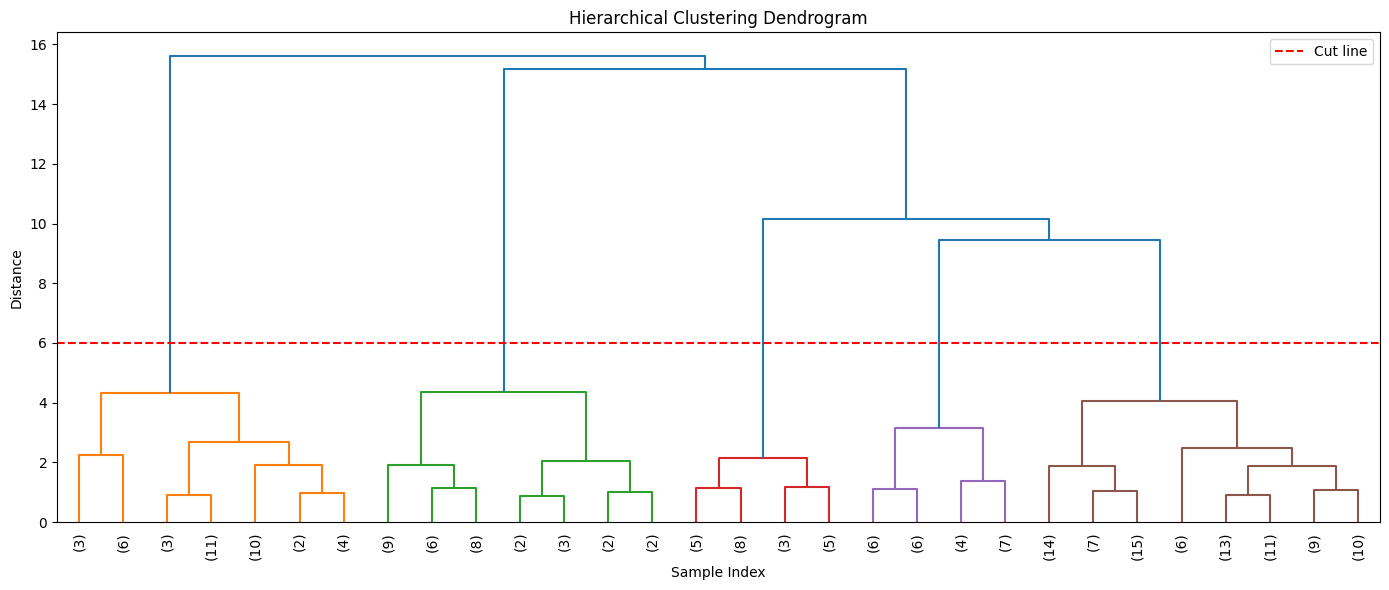

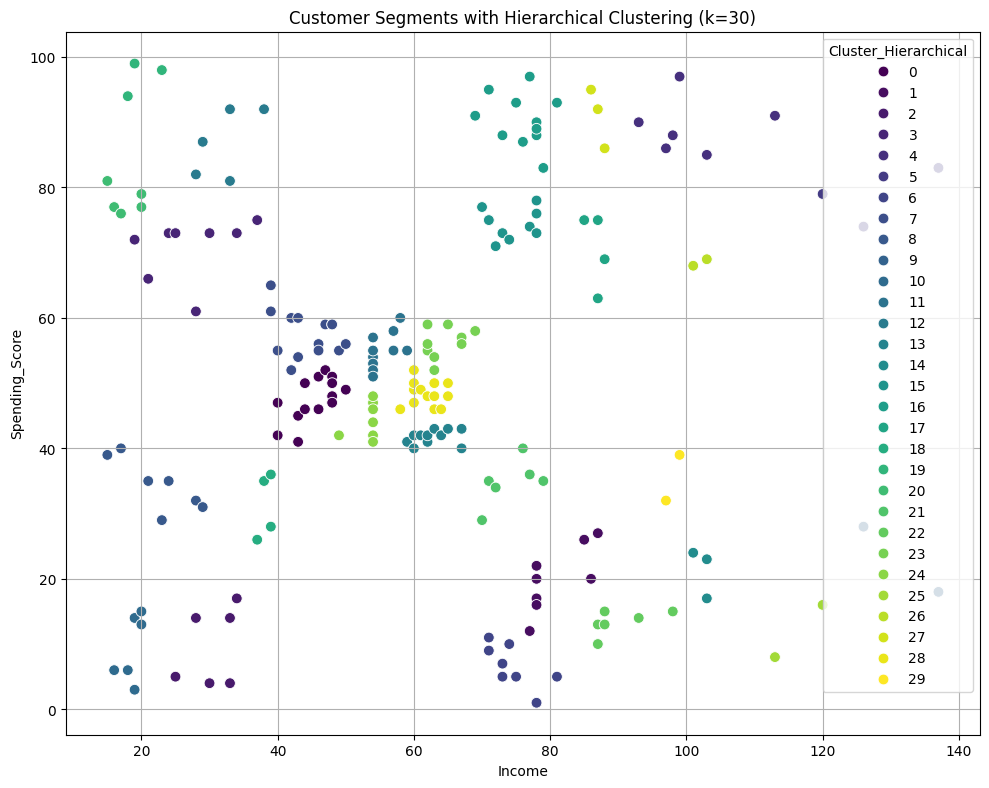

In [15]:
# Step 1: Perform hierarchical clustering
Z = linkage(X_scaled, method='ward')

# Step 2: Plot improved dendrogram (top 30 merges only)
plt.figure(figsize=(14, 6))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')

dendrogram(
    Z,
    truncate_mode='lastp',  # Only show the last p merged clusters
    p=30,                   # Show the largest 30 clusters
    show_leaf_counts=True,
    leaf_rotation=90.,
    leaf_font_size=10.,
    color_threshold=6       # Aligns with cut line (adjust as needed)
)

plt.axhline(y=6, color='r', linestyle='--', label='Cut line')
plt.legend()
plt.tight_layout()
plt.savefig("dendrogram.png", dpi=300)  # Save BEFORE plt.show()
plt.show()

# Step 3: Assign clusters using Agglomerative Clustering
optimal_k = 30  # Set to match top 30 clusters
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df['Cluster_Hierarchical'] = agg_clustering.fit_predict(X_scaled)

# Step 4: Visualize clusters in 2D (Income vs Spending_Score)
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Income',
    y='Spending_Score',
    hue='Cluster_Hierarchical',
    data=df,
    palette='viridis',
    s=60,
    legend='full'
)
plt.title(f'Customer Segments with Hierarchical Clustering (k={optimal_k})')
plt.grid(True)
plt.tight_layout()
plt.savefig("clusters.png", dpi=300)  # Save BEFORE plt.show()
plt.show()

### Analysis of Customer Segments

In [16]:
# # Analyze each cluster by computing mean values
# cluster_analysis = df.groupby('Cluster_KMeans').mean()
# print("Cluster analysis based on K-Means:")
# print(cluster_analysis)

# # Distribution of gender across clusters
# plt.figure(figsize=(12, 6))
# pd.crosstab(df['Cluster_KMeans'], df['Gender']).plot(kind='bar', stacked=True)
# plt.title('Gender Distribution Across Clusters')
# plt.xlabel('Cluster')
# plt.ylabel('Count')
# plt.xticks(rotation=0)
# plt.legend(title='Gender')
# plt.grid(axis='y')
# plt.show()

# # Visualize the clusters in 3D (adding Age as third dimension)
# from mpl_toolkits.mplot3d import Axes3D

# fig = plt.figure(figsize=(12, 10))
# ax = fig.add_subplot(111, projection='3d')

# ax.scatter(df['Income'], df['Spending_Score'], df['Age'], 
#            c=df['Cluster_KMeans'], cmap='viridis', s=60, alpha=0.8)

# ax.set_xlabel('Income')
# ax.set_ylabel('Spending Score')
# ax.set_zlabel('Age')
# ax.set_title('3D Visualization of Customer Segments')
# plt.show()

```
TypeError: Could not convert string 'Female' to numeric

TypeError: agg function failed [how->mean,dtype->object]
```

Cluster analysis based on K-Means (numeric features only):
                CustomerID        Age     Income  Spending_Score  \
Cluster_KMeans                                                     
0                86.320988  42.716049  55.296296       49.518519   
1               162.000000  32.692308  86.538462       82.128205   
2                23.090909  25.272727  25.727273       79.363636   
3               164.371429  41.114286  88.200000       17.114286   
4                23.000000  45.217391  26.304348       20.913043   

                Cluster_Hierarchical  
Cluster_KMeans                        
0                          14.148148  
1                          14.512821  
2                          11.272727  
3                          12.142857  
4                           8.695652  

Top 30 Customers per Cluster by Spending Score:
     CustomerID  Cluster_KMeans  Income  Spending_Score  Gender  Age
11           12               2      19              99  Female   35
19  

<Figure size 1200x600 with 0 Axes>

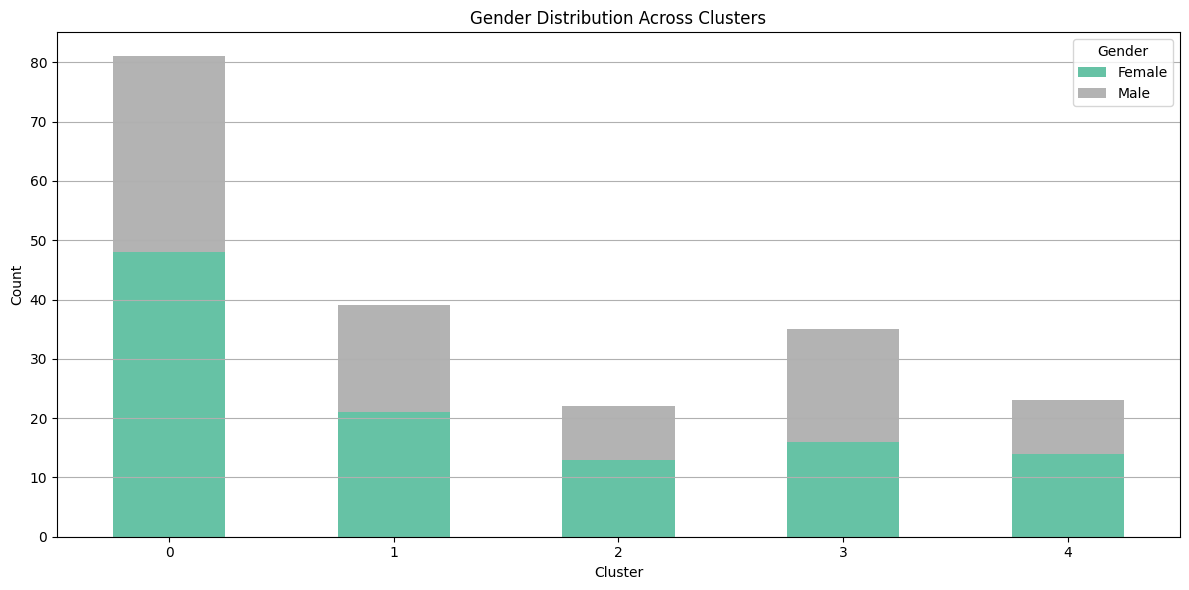

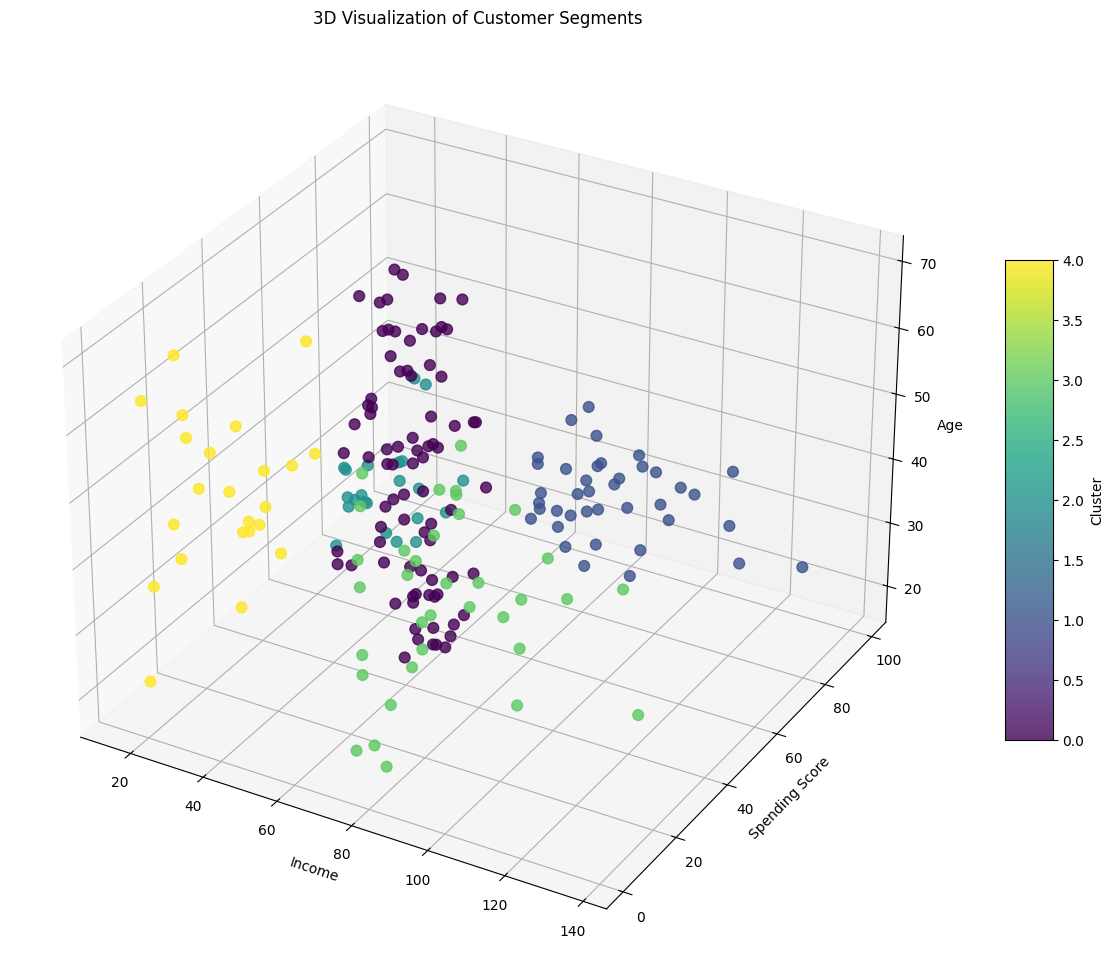

In [17]:
# ✅ Analyze each cluster by computing mean values (numeric_only=True is critical!)
cluster_analysis = df.groupby('Cluster_KMeans').mean(numeric_only=True)
print("Cluster analysis based on K-Means (numeric features only):")
print(cluster_analysis)

# ✅ Optional: View top 30 samples per cluster (based on Spending Score, for example)
top30 = df.sort_values(by='Spending_Score', ascending=False).groupby('Cluster_KMeans').head(30)
print("\nTop 30 Customers per Cluster by Spending Score:")
print(top30[['CustomerID', 'Cluster_KMeans', 'Income', 'Spending_Score', 'Gender', 'Age']])

# ✅ Gender distribution across clusters (better layout)
plt.figure(figsize=(12, 6))
gender_counts = pd.crosstab(df['Cluster_KMeans'], df['Gender'])
gender_counts.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('Gender Distribution Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ✅ 3D Visualization of clusters (Income, Spending Score, Age)
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df['Income'], df['Spending_Score'], df['Age'],
                c=df['Cluster_KMeans'], cmap='viridis', s=60, alpha=0.8)

ax.set_xlabel('Income')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Age')
ax.set_title('3D Visualization of Customer Segments')
plt.colorbar(sc, ax=ax, shrink=0.5, aspect=10, label='Cluster')
plt.tight_layout()
plt.show()

#### Updated Code with Top 30 Samples per Cluster for Better Visuals

Cluster analysis based on K-Means (numeric features only):
                CustomerID        Age     Income  Spending_Score  \
Cluster_KMeans                                                     
0                86.320988  42.716049  55.296296       49.518519   
1               162.000000  32.692308  86.538462       82.128205   
2                23.090909  25.272727  25.727273       79.363636   
3               164.371429  41.114286  88.200000       17.114286   
4                23.000000  45.217391  26.304348       20.913043   

                Cluster_Hierarchical  
Cluster_KMeans                        
0                          14.148148  
1                          14.512821  
2                          11.272727  
3                          12.142857  
4                           8.695652  

Top 30 Customers per Cluster by Spending Score:
     CustomerID  Cluster_KMeans  Income  Spending_Score  Gender  Age
11           12               2      19              99  Female   35
19  

<Figure size 1200x600 with 0 Axes>

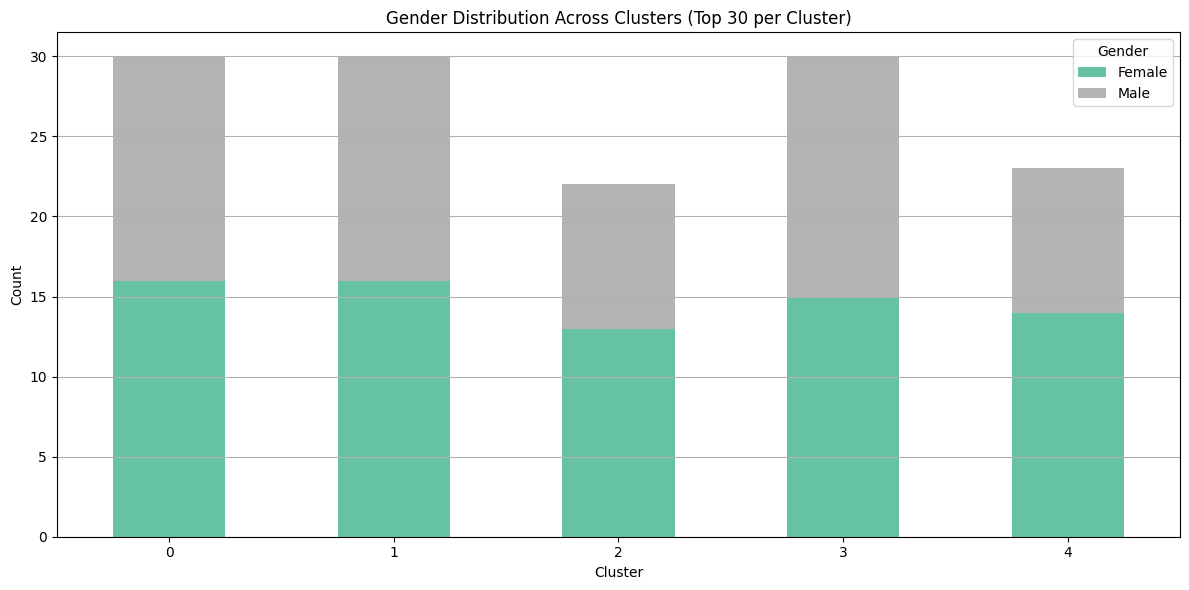

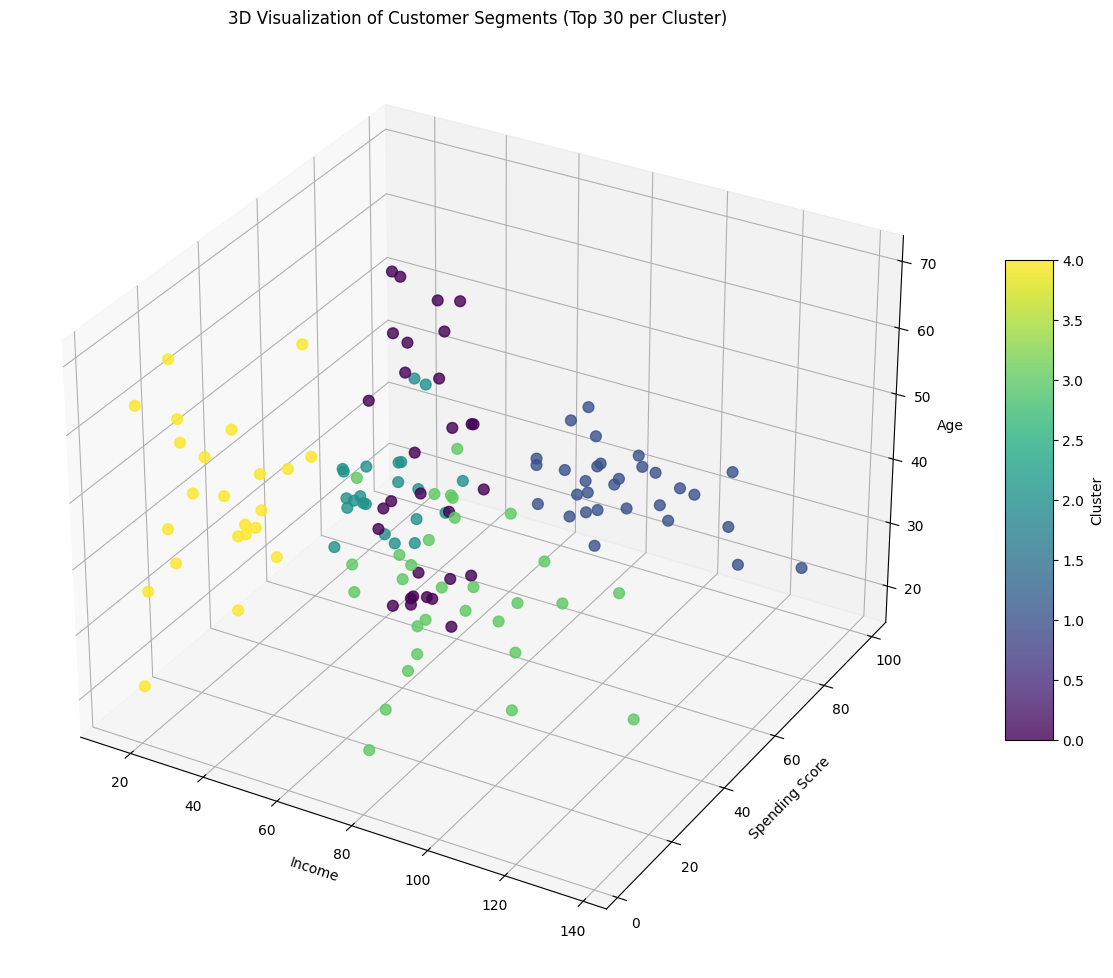

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# ✅ Fix: Compute cluster means using only numeric columns
cluster_analysis = df.groupby('Cluster_KMeans').mean(numeric_only=True)
print("Cluster analysis based on K-Means (numeric features only):")
print(cluster_analysis)

# ✅ Select top 30 customers per cluster based on Spending Score (for clearer visualizations)
top30 = df.sort_values(by='Spending_Score', ascending=False).groupby('Cluster_KMeans').head(30)
print("\nTop 30 Customers per Cluster by Spending Score:")
print(top30[['CustomerID', 'Cluster_KMeans', 'Income', 'Spending_Score', 'Gender', 'Age']])

# ✅ Gender distribution across clusters (based on top 30 customers)
plt.figure(figsize=(12, 6))
pd.crosstab(top30['Cluster_KMeans'], top30['Gender']).plot(kind='bar', stacked=True, colormap='Set2', figsize=(12, 6))
plt.title('Gender Distribution Across Clusters (Top 30 per Cluster)')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ✅ 3D Visualization of clusters using top 30 customers per cluster
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(top30['Income'], top30['Spending_Score'], top30['Age'], 
                c=top30['Cluster_KMeans'], cmap='viridis', s=60, alpha=0.8)

ax.set_xlabel('Income')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Age')
ax.set_title('3D Visualization of Customer Segments (Top 30 per Cluster)')
plt.colorbar(sc, ax=ax, shrink=0.5, aspect=10, label='Cluster')
plt.tight_layout()
plt.show()

### Marketing Strategy Based on Segments

In [19]:
# Describe each customer segment and suggest marketing strategies
segments = {
    0: "Budget-conscious customers (Low income, low spending score)",
    1: "Standard customers (Medium income, medium spending)",
    2: "Target customers (High income, high spending score)",
    3: "Potential targets (High income, lower spending score)",
    4: "Careful spenders (Low income, high spending score)"
}

for cluster_id, description in segments.items():
    cluster_data = df[df['Cluster_KMeans'] == cluster_id]
    print(f"\nCluster {cluster_id}: {description}")
    print(f"Number of customers: {len(cluster_data)}")
    print(f"Average age: {cluster_data['Age'].mean():.1f}")
    print(f"Average income: ${cluster_data['Income'].mean():.1f}k")
    print(f"Average spending score: {cluster_data['Spending_Score'].mean():.1f}/100")
    print("Gender distribution:")
    print(cluster_data['Gender'].value_counts(normalize=True).apply(lambda x: f"{x:.1%}"))
    
    print("\nSuggested marketing strategy:")
    if cluster_id == 0:
        print("- Focus on value and affordability")
        print("- Discount promotions and budget options")
        print("- Loyalty programs with monetary benefits")
    elif cluster_id == 1:
        print("- Balanced approach with moderate pricing")
        print("- Focus on quality-to-price ratio")
        print("- Cross-selling related products")
    elif cluster_id == 2:
        print("- Premium and luxury offerings")
        print("- Exclusive experiences and services")
        print("- VIP treatment and personalized recommendations")
    elif cluster_id == 3:
        print("- Focus on demonstrating product value")
        print("- Targeted promotions of premium products")
        print("- Customer education about product benefits")
    elif cluster_id == 4:
        print("- Special promotions and sales events")
        print("- Budget-friendly premium options")
        print("- Social media engagement and community building")
    print("-" * 50)


Cluster 0: Budget-conscious customers (Low income, low spending score)
Number of customers: 81
Average age: 42.7
Average income: $55.3k
Average spending score: 49.5/100
Gender distribution:
Gender
Female    59.3%
Male      40.7%
Name: proportion, dtype: object

Suggested marketing strategy:
- Focus on value and affordability
- Discount promotions and budget options
- Loyalty programs with monetary benefits
--------------------------------------------------

Cluster 1: Standard customers (Medium income, medium spending)
Number of customers: 39
Average age: 32.7
Average income: $86.5k
Average spending score: 82.1/100
Gender distribution:
Gender
Female    53.8%
Male      46.2%
Name: proportion, dtype: object

Suggested marketing strategy:
- Balanced approach with moderate pricing
- Focus on quality-to-price ratio
- Cross-selling related products
--------------------------------------------------

Cluster 2: Target customers (High income, high spending score)
Number of customers: 22
Avera

### Key Insights

1. We identified five distinct customer segments based on income and spending behavior.
2. The "Target customers" segment (high income, high spending) represents the most valuable customer group.
3. The "Potential targets" segment (high income, lower spending) presents the greatest opportunity for growth.
4. Age and gender distributions vary significantly across segments, suggesting different marketing approaches.
5. K-Means and Hierarchical Clustering produced similar segment structures, confirming the robustness of the analysis.

## Summary of the Three Case Studies

These three case studies demonstrate the application of different machine learning paradigms:

1. **Regression** for predicting continuous values (house prices)
2. **Classification** for predicting categories (customer churn)
3. **Clustering** for discovering natural groupings (customer segments)

Each case study followed a similar workflow:
- Problem definition
- Data exploration and preprocessing
- Model development
- Evaluation and interpretation
- Extracting business insights

The choice of algorithm depends on the specific problem type, with performance metrics tailored to each problem domain (RMSE for regression, accuracy/AUC for classification, silhouette score for clustering).